In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/ba2lll/ubl-price/UBL.csv


### Imports, load and clean

In [15]:
import numpy as np, pandas as pd
import tensorflow as tf
from tensorflow.keras import Sequential, layers, callbacks
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error as MAE, mean_squared_error as MSE, r2_score

df = pd.read_csv("/kaggle/input/datasets/ba2lll/ubl-price/UBL.csv")
df.columns = df.columns.str.strip().str.upper()
df["DATE"] = pd.to_datetime(df["DATE"])
df = df[df["DATE"] >= "2021-01-01"].drop_duplicates()
ok = ((df[["OPEN","HIGH","LOW","CLOSE"]] > 0).adf["ret"] = np.log(df.CLOSE).diff()
df["hl_range"] = (df.HIGH - df.LOW) / df.CLOSE
df["oc_change"] = (df.CLOSE - df.OPEN) / df.OPEN
df["log_vol"] = np.log1p(df.VOLUME)
df["ma5_ratio"] = df.CLOSE / df.CLOSE.rolling(5).mean() - 1
df["ma20_ratio"] = df.CLOSE / df.CLOSE.rolling(20).mean() - 1
df["vol10"] = df.ret.rolling(10).std()
df["target_ret"] = df.ret.shift(-1)          # next-day log return
df["tdate"] = df.DATE.shift(-1)              # date being predicted
df["next_close"] = df.CLOSE.shift(-1)
df = df.dropna().reset_index(drop=True)ll(axis=1) & (df["VOLUME"] >= 0)
      & (df["HIGH"] >= df[["OPEN","CLOSE","LOW"]].max(axis=1))
      & (df["LOW"] <= df[["OPEN","CLOSE","HIGH"]].min(axis=1)))
df = df[ok].sort_values("DATE")
df = df[(df.DATE >= "2021-09-30") & (df.DATE <= "2026-06-30")].reset_index(drop=True)
assert df.DATE.is_unique
print(len(df), df.DATE.min(), df.DATE.max())

1176 2021-09-30 00:00:00 2026-06-30 00:00:00


In [17]:
df.head()

,DATE,OPEN,HIGH,LOW,CLOSE,VOLUME,CHANGE
0,2021-09-30,117.33,119.00,116.00,118.56,2127141,1.41
1,2021-10-01,118.00,119.45,117.05,117.83,506091,-0.73
2,2021-10-04,115.15,118.95,115.15,118.37,756631,0.54
3,2021-10-05,118.50,120.68,117.50,120.01,1526238,1.64
4,2021-10-06,120.90,122.49,119.00,121.92,1925997,1.91


### Features and target

In [18]:
df["ret"] = np.log(df.CLOSE).diff()
df["hl_range"] = (df.HIGH - df.LOW) / df.CLOSE
df["oc_change"] = (df.CLOSE - df.OPEN) / df.OPEN
df["log_vol"] = np.log1p(df.VOLUME)
df["ma5_ratio"] = df.CLOSE / df.CLOSE.rolling(5).mean() - 1
df["ma20_ratio"] = df.CLOSE / df.CLOSE.rolling(20).mean() - 1
df["vol10"] = df.ret.rolling(10).std()
df["target_ret"] = df.ret.shift(-1)          # next-day log return
df["tdate"] = df.DATE.shift(-1)              # date being predicted
df["next_close"] = df.CLOSE.shift(-1)
df = df.dropna().reset_index(drop=True)

### Windows, split & scaling

In [19]:
feats = ["ret","hl_range","oc_change","log_vol","ma5_ratio","ma20_ratio","vol10"]
W = 30
X, y, td, pc, nc = [], [], [], [], []
for i in range(W-1, len(df)):
    X.append(df[feats].iloc[i-W+1:i+1].values)
    y.append(df.target_ret.iloc[i]); td.append(df.tdate.iloc[i])
    pc.append(df.CLOSE.iloc[i]); nc.append(df.next_close.iloc[i])
X, y, pc, nc = map(np.array, (X, y, pc, nc))
td = pd.to_datetime(td)

tr = np.asarray(td <= pd.Timestamp("2025-01-23"))
va = np.asarray((td > pd.Timestamp("2025-01-23")) & (td <= pd.Timestamp("2025-10-10")))
te = np.asarray(td > pd.Timestamp("2025-10-10"))
print(tr.sum(), va.sum(), te.sum())

sx = StandardScaler().fit(X[tr].reshape(-1, len(feats)))      # fit on train only
sc = lambda a: sx.transform(a.reshape(-1, len(feats))).reshape(a.shape)
Xtr, Xva, Xte = sc(X[tr]), sc(X[va]), sc(X[te])
sy = StandardScaler().fit(y[tr].reshape(-1,1))
ytr, yva = sy.transform(y[tr].reshape(-1,1)), sy.transform(y[va].reshape(-1,1))

774 176 177


### Metrics and naive baseline

In [20]:
def report(name, actual, pred, prev):
    mape = np.mean(np.abs((actual-pred)/actual))*100
    da = np.mean(np.sign(actual-prev) == np.sign(pred-prev))*100
    print(f"{name}: MAE {MAE(actual,pred):.2f} RMSE {np.sqrt(MSE(actual,pred)):.2f} "
          f"MAPE {mape:.2f}% R2 {r2_score(actual,pred):.3f} DirAcc {da:.1f}%")

report("Naive (yesterday's close)", nc[te], pc[te], pc[te])

Naive (yesterday's close): MAE 7.86 RMSE 11.10 MAPE 1.94% R2 0.942 DirAcc 0.0%


### MLP baseline

In [21]:
tf.random.set_seed(42); np.random.seed(42)
Xtr_f, Xva_f, Xte_f = [a.reshape(len(a), -1) for a in (Xtr, Xva, Xte)]

mlp = Sequential([
    layers.Input((Xtr_f.shape[1],)),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.2),
    layers.Dense(32, activation="relu"),
    layers.Dense(1)])
mlp.compile("adam", "mse")
mlp.fit(Xtr_f, ytr, validation_data=(Xva_f, yva), epochs=100, batch_size=32,
        callbacks=[callbacks.EarlyStopping(patience=15, restore_best_weights=True)])

pred_ret = sy.inverse_transform(mlp.predict(Xte_f)).ravel()
report("MLP (price)", nc[te], pc[te] * np.exp(pred_ret), pc[te])

Epoch 1/100


2026-10-07 16:21:25.095006: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.6018 - val_loss: 12.6054
Epoch 2/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.1054 - val_loss: 12.0368
Epoch 3/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.9522 - val_loss: 11.8213
Epoch 4/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.8268 - val_loss: 11.8988
Epoch 5/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.7813 - val_loss: 11.7338
Epoch 6/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.7407 - val_loss: 11.7017
Epoch 7/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.6540 - val_loss: 11.5677
Epoch 8/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.6541 - val_loss: 11.5911
Epoch 9/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.5694 - val_loss: 11.6946
Epoch 10/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.5782 - val_loss: 11.7841
Epoch 11/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.5082 - val_loss: 11.9776
Epoch 12/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.4

### LSTM

In [22]:
tf.random.set_seed(42); np.random.seed(42)
lstm = Sequential([
    layers.Input((W, len(feats))),
    layers.LSTM(64),
    layers.Dropout(0.2),
    layers.Dense(32, activation="relu"),
    layers.Dense(1)])
lstm.compile("adam", "mse")
lstm.fit(Xtr, ytr, validation_data=(Xva, yva), epochs=100, batch_size=32,
         callbacks=[callbacks.EarlyStopping(patience=15, restore_best_weights=True)])

pred_ret = sy.inverse_transform(lstm.predict(Xte)).ravel()
pred_close = pc[te] * np.exp(pred_ret)
report("LSTM", nc[te], pred_close, pc[te])

pd.DataFrame({"DATE": td[te], "Actual Close": nc[te], "Predicted Close": pred_close}
            ).to_csv("lstm_price_predictions.csv", index=False)

Epoch 1/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 1.0214 - val_loss: 10.8164
Epoch 2/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.9891 - val_loss: 10.8006
Epoch 3/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.9684 - val_loss: 10.7950
Epoch 4/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.9695 - val_loss: 10.7636
Epoch 5/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.9590 - val_loss: 10.7823
Epoch 6/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.9490 - val_loss: 10.7863
Epoch 7/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.9314 - val_loss: 10.8009
Epoch 8/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.9151 - val_loss: 10.7931
Epoch 9/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.9306 - val_loss: 10.8317
Epoch 10/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.9108 - val_loss: 10.8661
Epoch 11/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.9017 - val_loss: 10.7536
Epoch 12/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0

### Validation scores & plots

In [23]:
pc_v, nc_v = pc[va], nc[va]
report("Naive  [val]", nc_v, pc_v, pc_v)
r = sy.inverse_transform(mlp.predict(Xva_f)).ravel()
report("MLP    [val]", nc_v, pc_v*np.exp(r), pc_v)
r = sy.inverse_transform(lstm.predict(Xva)).ravel()
report("LSTM   [val]", nc_v, pc_v*np.exp(r), pc_v)

Naive  [val]: MAE 7.72 RMSE 22.32 MAPE 2.04% R2 0.881 DirAcc 0.0%
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
MLP    [val]: MAE 9.54 RMSE 22.79 MAPE 2.54% R2 0.876 DirAcc 53.4%
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
LSTM   [val]: MAE 8.37 RMSE 22.26 MAPE 2.19% R2 0.881 DirAcc 54.5%


6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


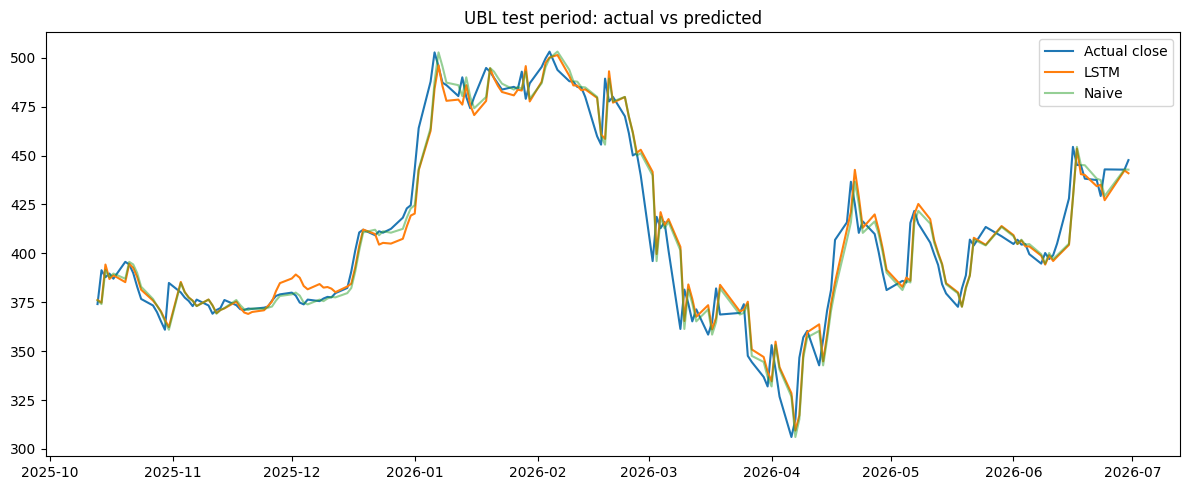

In [24]:
import matplotlib.pyplot as plt
pred_close = pc[te] * np.exp(sy.inverse_transform(lstm.predict(Xte)).ravel())
plt.figure(figsize=(12,5))
plt.plot(td[te], nc[te], label="Actual close")
plt.plot(td[te], pred_close, label="LSTM")
plt.plot(td[te], pc[te], label="Naive", alpha=0.5)
plt.legend(); plt.title("UBL test period: actual vs predicted"); plt.tight_layout()
plt.savefig("actual_vs_pred.png", dpi=150); plt.show()

### Window size search

In [25]:
def run_window(W, units=64):
    Xw, yw, tdw, pcw, ncw = [], [], [], [], []
    for i in range(W-1, len(df)):
        Xw.append(df[feats].iloc[i-W+1:i+1].values)
        yw.append(df.target_ret.iloc[i]); tdw.append(df.tdate.iloc[i])
        pcw.append(df.CLOSE.iloc[i]); ncw.append(df.next_close.iloc[i])
    Xw, yw, pcw, ncw = map(np.array, (Xw, yw, pcw, ncw))
    tdw = pd.to_datetime(tdw)
    trw = np.asarray(tdw <= pd.Timestamp("2025-01-23"))
    vaw = np.asarray((tdw > pd.Timestamp("2025-01-23")) & (tdw <= pd.Timestamp("2025-10-10")))
    sxw = StandardScaler().fit(Xw[trw].reshape(-1, len(feats)))
    scw = lambda a: sxw.transform(a.reshape(-1, len(feats))).reshape(a.shape)
    syw = StandardScaler().fit(yw[trw].reshape(-1,1))
    tf.random.set_seed(42); np.random.seed(42)
    m = Sequential([layers.Input((W, len(feats))), layers.LSTM(units),
                    layers.Dropout(0.2), layers.Dense(32, activation="relu"), layers.Dense(1)])
    m.compile("adam", "mse")
    m.fit(scw(Xw[trw]), syw.transform(yw[trw].reshape(-1,1)),
          validation_data=(scw(Xw[vaw]), syw.transform(yw[vaw].reshape(-1,1))),
          epochs=100, batch_size=32, verbose=0,
          callbacks=[callbacks.EarlyStopping(patience=15, restore_best_weights=True)])
    r = syw.inverse_transform(m.predict(scw(Xw[vaw]), verbose=0)).ravel()
    pred = pcw[vaw] * np.exp(r)
    return np.mean(np.abs((ncw[vaw]-pred)/ncw[vaw]))*100, np.mean(np.abs((ncw[vaw]-pcw[vaw])/ncw[vaw]))*100

for W_try in [10, 20, 30, 60]:
    lstm_mape, naive_mape = run_window(W_try)
    print(f"W={W_try}: LSTM val MAPE {lstm_mape:.2f}% | naive {naive_mape:.2f}%")

W=10: LSTM val MAPE 2.03% | naive 2.04%
W=20: LSTM val MAPE 2.03% | naive 2.04%
W=30: LSTM val MAPE 2.08% | naive 2.04%
W=60: LSTM val MAPE 2.03% | naive 2.04%
